# Alpha Quest CTA Research

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [2]:
blog_path = os.getcwd()
res_path  = os.path.abspath(os.path.join(blog_path, ".."))
repo_path = os.path.abspath(os.path.join(res_path, ".."))
data_path = os.path.join(repo_path, "data")

In [3]:
tool_path = os.path.join(repo_path, "src", "Tools")
sys.path.append(tool_path)

from AlphaQuestTools import AQTools

# AlphaQuest CTA Research Series #1 - Black Box Trend Following – Lifting the Veil 

In [51]:
fut_path   = os.path.join(data_path, "FuturesData", "PrepFuturesPX.parquet")
df_fut_raw = pd.read_parquet(path = fut_path, engine = "pyarrow")

In [52]:
idx_path = os.path.join(data_path, "TrendIndices", "TrendIndicesGuide.xlsx")

df_ticker = (pd.read_excel(
    io = idx_path, sheet_name = "IndexReplication").
    query("group == 'AlphaQuest'").
    assign(tmp = lambda x: x.ticker.str.replace(" 1", "1").str.replace(" ", "_").str.lower()))

In [53]:
tickers = df_ticker.tmp.drop_duplicates().sort_values().to_list()
df_fut_sliced = df_fut_raw.query("ticker == @tickers")

In [54]:
def _channel_breakout(df: pd.DataFrame, window: int = 50) -> pd.DataFrame:

    df_out = (
        df.sort_values("date")
        .assign(
            px_rtn    = lambda x: x.adj_val.pct_change(),
            high_close=lambda x: x.adj_val.rolling(window=window).max(),
            low_close=lambda x: x.adj_val.rolling(window=window).min(),
            signal=lambda x:
                np.where(x.adj_val == x.high_close, 1, 0)
                + np.where(x.adj_val == x.low_close, -1, 0),
        )
        .assign(
            signal=lambda x: x.signal.replace(0, np.nan).ffill(),
            lag_signal=lambda x: x.signal.shift(),
        )
    )

    return df_out

channel_window = 50

df_channel_breakout = (df_fut_sliced.groupby(
    "ticker").
    apply(_channel_breakout, channel_window).
    reset_index().
    drop(columns = ["level_1"]).
    assign(signal_rtn = lambda x: np.sign(x.lag_signal) * x.px_rtn))

In [55]:
def _ma_crossover(df: pd.DataFrame, small_window: int = 10, big_window: int = 100) -> pd.DataFrame:

    df_out = (df.sort_values(
        "date").
        assign(
            px_rtn     = lambda x: x.adj_val.pct_change(),
            small_ma   = lambda x: x.adj_val.rolling(window = small_window).mean(),
            big_ma     = lambda x: x.adj_val.rolling(window = big_window).mean(),
            signal     = lambda x: x.small_ma - x.big_ma,
            lag_signal = lambda x: x.signal.shift()))

    return df_out

small_window    = 10
big_window      = 100
df_ma_crossover = (df_fut_sliced.
    groupby("ticker").
    apply(_ma_crossover, small_window, big_window).
    reset_index().
    drop(columns = ["level_1"]).
    assign(signal_rtn = lambda x: np.sign(x.lag_signal) * x.px_rtn))

In [56]:
df_signal_rtn = (pd.concat([
    df_ma_crossover[["date", "ticker", "signal_rtn"]].assign(signal = "MaCrossover"),
    df_channel_breakout[["date", "ticker", "signal_rtn"]].assign(signal = "ChannelBreakout")]))

To keep consistency with their author's approach they've analyzed the returns calculaing the NAV of each strategy and then taking the daily difference in account value as the standard deviation. Therefore we'll do something similar. Since non-integer positions are being used the starting values are irrelevant. 

In [57]:
df_account_pnl = (df_signal_rtn.pivot(
    index = "date", columns = ["ticker", "signal"], values = "signal_rtn").
    apply(lambda x: np.cumprod(1 + x) * 100).
    diff())

They don't state which kind of standard deviation they are using although its likely exponentially-weighted. They do say that they target a 1% PnL and use a window of about 100 days. We'll also account for contemperanous vs lagged hedging.

In [58]:
df_ewma_lag = (df_account_pnl.apply(
    lambda x: 0.01 / x.ewm(span = 100, adjust = False).std()).
    shift().
    reset_index().
    melt(id_vars = [("date", "")], value_name = "weight").
    rename(columns = {("date", ""): "date"}).
    dropna().
    assign(method = "ewma_lag"))

df_ewma = (df_account_pnl.apply(
    lambda x: 0.01 / x.ewm(span = 100, adjust = False).std()).
    reset_index().
    melt(id_vars = [("date", "")], value_name = "weight").
    rename(columns = {("date", ""): "date"}).
    dropna().
    assign(method = "ewma"))

In [59]:
df_weighted_rtn = (pd.concat([
    df_ewma_lag, df_ewma]).
    merge(right = df_signal_rtn, how = "inner", on = ["date", "ticker", "signal"]).
    assign(weighted_rtn = lambda x: x.weight * x.signal_rtn))

df_combined = (df_weighted_rtn[
    ["date", "signal", "method", "weighted_rtn"]].
    groupby(["date", "signal", "method"]).
    agg("mean").
    reset_index())

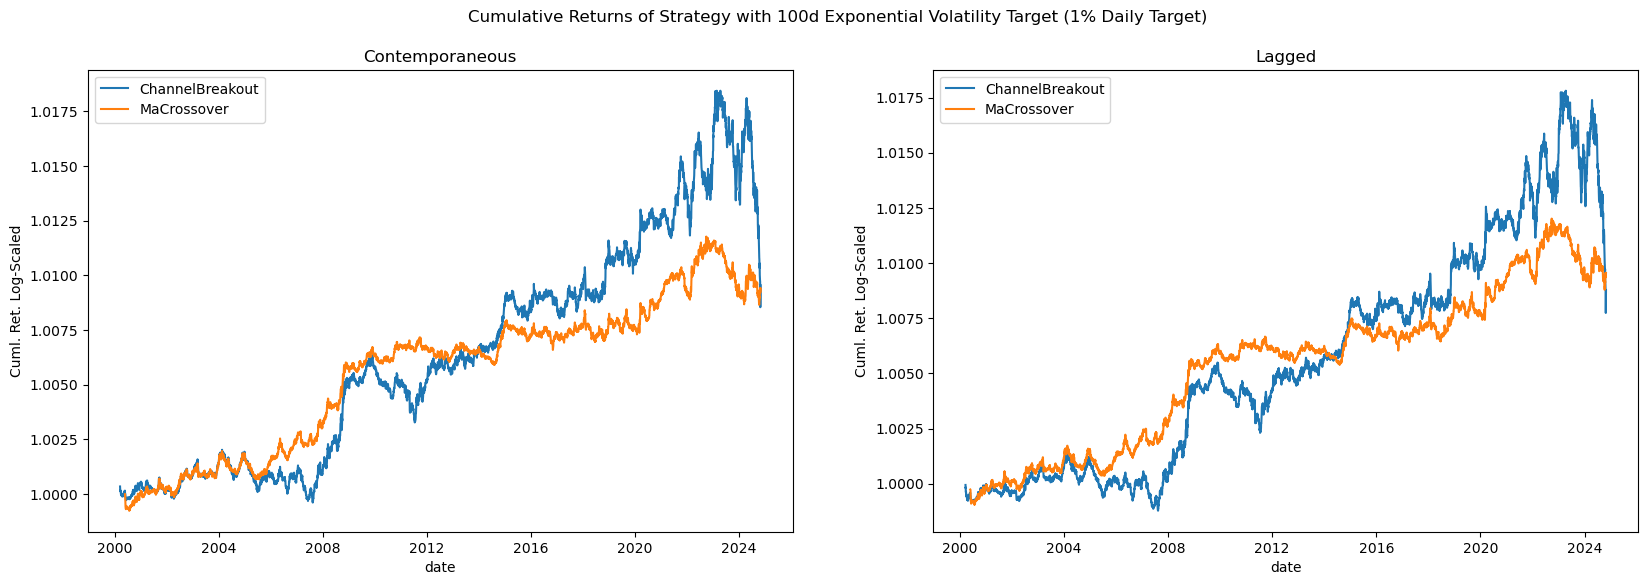

In [60]:
methods   = df_combined.method.drop_duplicates().sort_values().to_list()
fig, axes = plt.subplots(ncols = 2, figsize = (20,6))

method_renamer = {
    "ewma"    : "Contemporaneous",
    "ewma_lag": "Lagged"}

for method, ax in zip(methods, axes.flatten()): 

    (df_combined.query(
        "method == @method").
        rename(columns = {"signal": ""}).
        pivot(index = "date", columns = "", values = "weighted_rtn").
        apply(lambda x: np.cumprod(1 + x)).
        plot(
            ax     = ax,
            ylabel = "Cuml. Ret. Log-Scaled",
            title  = method_renamer[method]))

fig.suptitle("Cumulative Returns of Strategy with 100d Exponential Volatility Target (1% Daily Target)")
plt.show()

The volatility target for account differences isn't giving enough weights bring the gross return down. Therefore the same approach will be used but rather than volatliity targeting the PnL of the NAV the raw returns will be used. 

In [61]:
def vol_target(df_signal_rtn: pd.DataFrame, vol_target: int = 0.01) -> pd.DataFrame:

    df_wider = (df_signal_rtn.pivot(
        index = "date", columns = ["signal", "ticker"], values = "signal_rtn"))
    
    df_ewma = (df_wider.apply(
        lambda x: x * (vol_target / (x.ewm(span = 100, adjust = False).std()))).
        reset_index().
        melt(id_vars = [("date", "")]).
        rename(columns = {("date", ""): "date"}).
        drop(columns = ["ticker"]).
        groupby(["date", "signal"]).
        agg("mean").
        reset_index().
        assign(method = "ewma"))
    
    df_ewma_lag = (df_wider.apply(
        lambda x: x * (vol_target / (x.ewm(span = 100, adjust = False).std().shift()))).
        reset_index().
        melt(id_vars = [("date", "")]).
        rename(columns = {("date", ""): "date"}).
        drop(columns = ["ticker"]).
        groupby(["date", "signal"]).
        agg("mean").
        reset_index().
        assign(method = "ewma_lag"))
    
    df_combined_port = (pd.concat([
        df_ewma, df_ewma_lag]).
        dropna().
        rename(columns = {"value": "rtn"}).
        assign(target = vol_target))

    return df_combined_port

In [62]:
df_ports = pd.concat([
    vol_target(df_signal_rtn),
    vol_target(df_signal_rtn, 0.03)])

In [63]:
df_tmp_port = df_ports.query("target == 0.01")

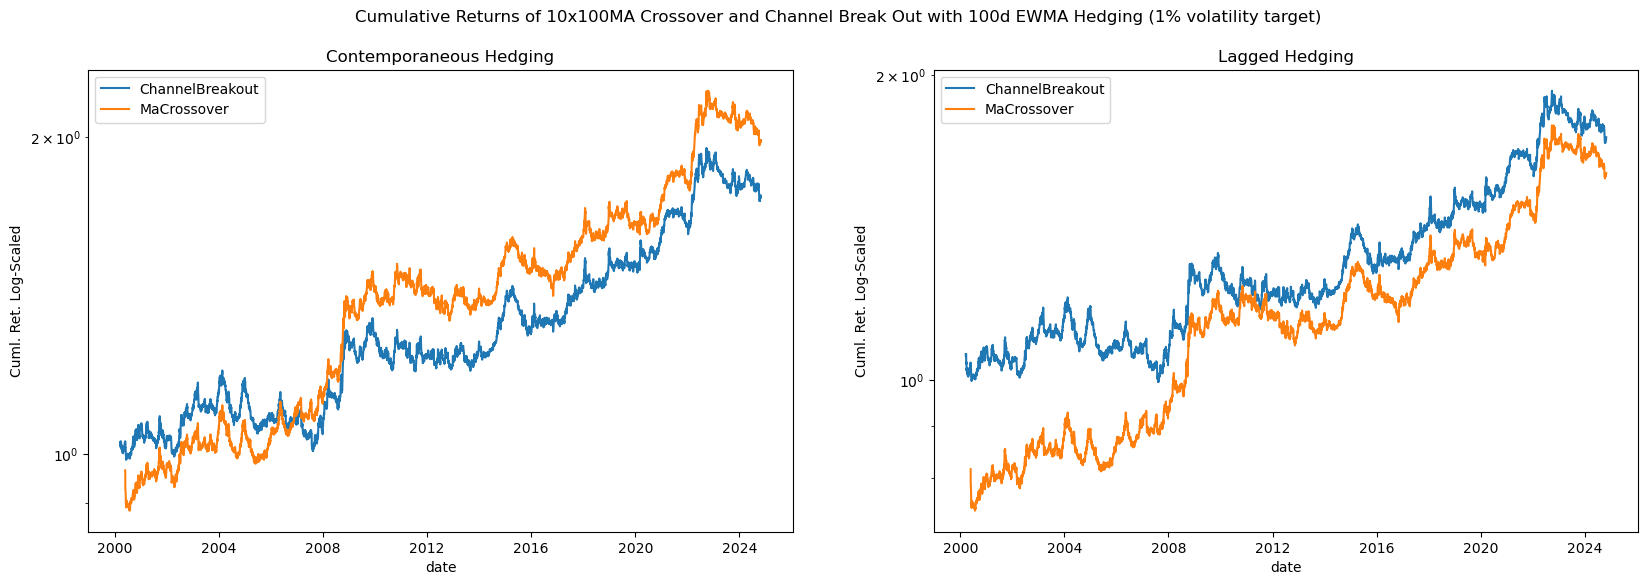

In [64]:
groups    = df_tmp_port.method.drop_duplicates().sort_values().to_list()
fig, axes = plt.subplots(ncols = len(groups), figsize = (20,6))

for group, ax in zip(groups, axes.flatten()): 

    (df_tmp_port.query(
        "method == @group").
        rename(columns = {"signal": ""}).
        pivot(index = "date", columns = "", values = "rtn").
        apply(lambda x: np.cumprod(1 + x)).
        plot(
            ax     = ax,
            logy   = True,
            ylabel = "Cuml. Ret. Log-Scaled",
            title  = method_renamer[group] + " Hedging"))

fig.suptitle("Cumulative Returns of 10x100MA Crossover and Channel Break Out with 100d EWMA Hedging (1% volatility target)")
plt.show()

In [48]:
path     = r"A:\2026BlpAdHocData\Combined\PX"
cta_path = os.path.join(path, "hf_indices.parquet")
tre_path = os.path.join(path, "TrendIndices.parquet")

In [49]:
df_cta = (pd.read_parquet(
    path = cta_path, engine = "pyarrow").
    query("security == ['NEIXCTA Index']").
    assign(security = lambda x: x.security.str.split(" ").str[0]).
    pivot(index = "date", columns = "security", values = "PX_LAST").
    dropna().
    pct_change())

In [44]:
df_trend = (pd.read_parquet(
    path = tre_path, engine = "pyarrow").
    query("security == 'NEIXCTAT Index'").
    assign(security = lambda x: x.security.str.split(" ").str[0]).
    pivot(index = "date", columns = "security", values = "PX_LAST").
    pct_change())

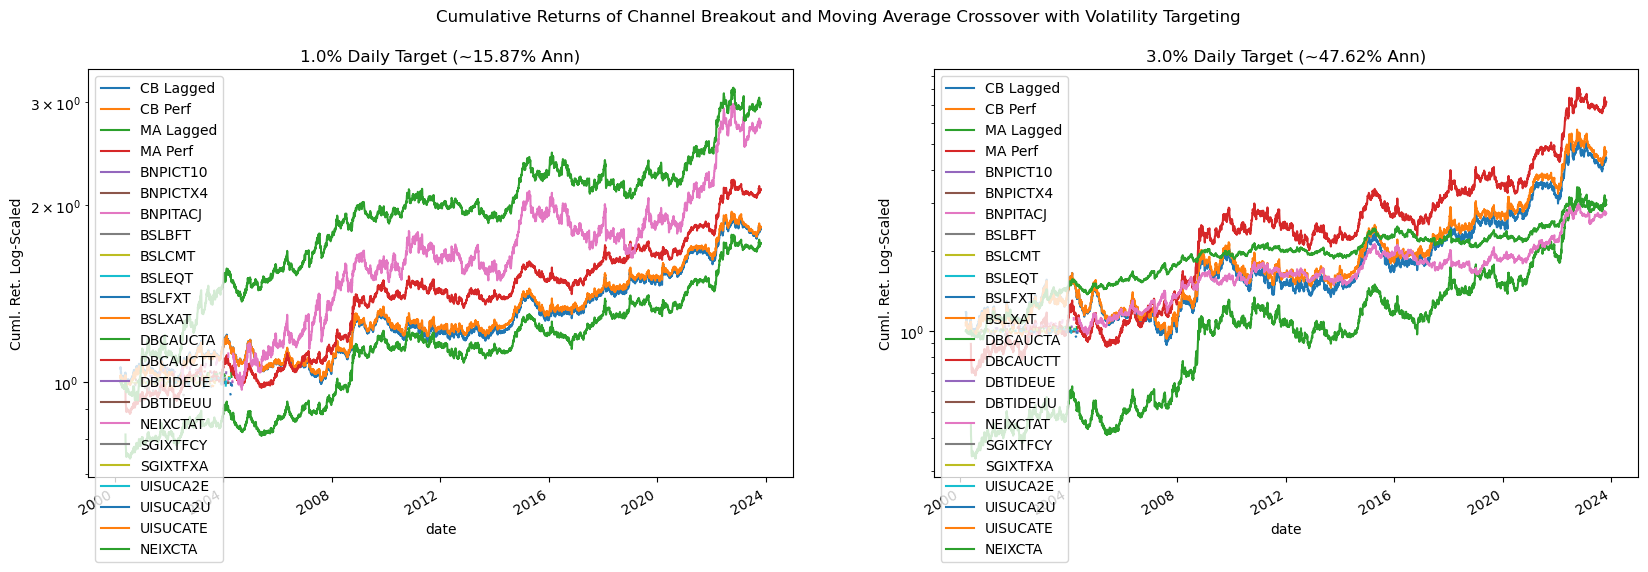

In [45]:
targets = df_ports.target.drop_duplicates().sort_values().to_list()
fig, axes = plt.subplots(ncols = len(targets), figsize = (20,6))

for target, ax in zip(targets, axes.flatten()): 

    df_combined = (df_ports.query(
        "target == @target").
        assign(
            date = lambda x: pd.to_datetime(x.date),
            name = lambda x: 
                np.where(x.signal == "ChannelBreakout", "CB", "MA") + 
                " " + 
                np.where(x.method == "ewma", "Perf", "Lagged")).
        pivot(index = "date", columns = "name", values = "rtn").
        merge(right = df_trend, how = "inner", on = ["date"]).
        merge(right = df_cta, how = "inner", on = ["date"]).
        apply(lambda x: np.cumprod(1 + x)).
        plot(
            logy   = True,
            ax     = ax,
            ylabel = "Cuml. Ret. Log-Scaled",
            title  = "{}% Daily Target (~{}% Ann)".format(target * 100, np.round(target * 100 * np.sqrt(252), 2))))

fig.suptitle("Cumulative Returns of Channel Breakout and Moving Average Crossover with Volatility Targeting")
plt.show()

In [23]:
renamer = {
    "ChannelBreakout": "CB",
    "MaCrossover"    : "MA",
    "ewma"           : "Perf",
    "ewma_lag"       : "Lag"}

df_port = (df_ports.query(
    "target == 0.03").
    replace(renamer).
    assign(
        date = lambda x: pd.to_datetime(x.date),
        name = lambda x: x.signal + " " + x.method).
    pivot(index = "date", columns = "name", values = "rtn").
    dropna())

In [24]:
df_combined = (df_port.merge(
    right = df_trend, how = "inner", on = ["date"]).
    merge(right = df_cta, how = "inner", on = ["date"]))

In [25]:
AQTools().get_perform_results(df_combined)

,CAGR,MaxDD,Ann. Vol.,Ann. Rtn / MaxDD,Sharpe
variable,,,,,
CB Lag,0.060716,-0.254580,0.012232,0.298191,0.390956
CB Perf,0.064125,-0.263158,0.011771,0.294993,0.415444
MA Lag,0.049177,-0.188424,0.014325,0.405794,0.336226
MA Perf,0.092757,-0.196942,0.012016,0.528591,0.545747
NEIXCTAT,0.062012,-0.229885,0.008073,0.289219,0.518779
NEIXCTA,0.047444,-0.165011,0.005150,0.292252,0.589861


In [26]:
path   = os.path.join(data_path, "FuturesData", "PrepFuturesPX.parquet")
df_spx = (pd.read_parquet(
    path = path, engine = "pyarrow").
    query("ticker == 'es1_index'")
    [["date", "adj_val"]].
    assign(date = lambda x: pd.to_datetime(x.date)).
    set_index("date").
    pct_change().
    rename(columns = {"adj_val": "spx"}))

In [27]:
df_endogs = (df_spx.merge(
    right = df_trend, how = "inner", on = ["date"]).
    merge(right = df_cta, how = "inner", on = ["date"]).
    dropna())

In [28]:
def _ols_params(df: pd.DataFrame) -> pd.DataFrame:

    model = (sm.OLS(
        endog = df.endog_rtn,
        exog  = sm.add_constant(df.exog_rtn)).
        fit())

    df_param   = model.params.to_frame(name = "param_val").reset_index()
    df_pvalues = model.pvalues.to_frame(name = "pvalues").reset_index()
    df_tvalues = model.tvalues.to_frame(name = "tvalues").reset_index()

    df_out = (df_param.merge(
        right = df_pvalues, how = "inner", on = ["index"]).
        merge(right = df_tvalues, how = "inner", on = ["index"]))

    return df_out

df_combined = (df_endogs.reset_index().melt(
    id_vars = "date", var_name = "exog_ticker", value_name = "exog_rtn").
    merge(right = df_port, how = "inner", on = ["date"]).
    melt(id_vars = ["date", "exog_ticker", "exog_rtn"], var_name = "endog_ticker", value_name = "endog_rtn"))

In [29]:
(df_combined.
    assign(group_var = lambda x: x.exog_ticker + "-" + x.endog_ticker).
    groupby("group_var").
    apply(_ols_params).
    reset_index().
    drop(columns = ["level_1"]).
    assign(
        exog_ticker  = lambda x: x.group_var.str.split("-").str[0],
        endog_ticker = lambda x: x.group_var.str.split("-").str[1]).
    drop(columns = ["group_var"]).
    melt(id_vars = ["endog_ticker", "exog_ticker", "index"]).
    replace({
        "spx"      : "SPX",
        "param_val": "Param. Val",
        "pvalues"  : r"$p$-values",
        "tvalues"  : r"$t$-values",
        "const"    : r"$\alpha$",
        "exog_rtn" : r"$\beta$"}).
    rename(columns = {
        "variable"   : "",
        "exog_ticker" : "Benchmark",
        "endog_ticker": "Strategy",
        "index"       : "param"}).
    pivot(index = ["Strategy", "param"], columns = ["", "Benchmark"], values = "value"))

Param. Val                         $p$-values            \
Benchmark            NEIXCTA      NEIXCTAT       SPX    NEIXCTA  NEIXCTAT   
Strategy param                                                              
CB Lag   $\alpha$  -0.000054 -2.141122e-05  0.000282   0.650111  0.855491   
         $\beta$    1.528943  9.906096e-01 -0.219810   0.000000  0.000000   
CB Perf  $\alpha$  -0.000032 -4.853609e-07  0.000292   0.777294  0.996567   
         $\beta$    1.481297  9.588072e-01 -0.207002   0.000000  0.000000   
MA Lag   $\alpha$  -0.000054 -1.760719e-05  0.000299   0.714709  0.905319   
         $\beta$    1.644102  1.058219e+00 -0.203675   0.000000  0.000000   
MA Perf  $\alpha$   0.000075  1.111998e-04  0.000416   0.503414  0.318134   
         $\beta$    1.586985  1.018578e+00 -0.197152   0.000000  0.000000   

                                $t$-values                        
Benchmark                   SPX    NEIXCTA   NEIXCTAT        SPX  
Strategy param                                                    
CB Lag   $\alpha$  6.659112e-02  -0.453630  -0.182124   1.834761  
         $\beta$   4.436586e-67  66.989601  68.866015 -17.524739  
CB Perf  $\alpha$  4.906185e-02  -0.282860  -0.004303   1.968458  
         $\beta$   3.909027e-64  67.683671  69.474625 -17.114771  
MA Lag   $\alpha$  1.023654e-01  -0.365557  -0.118951   1.633745  
         $\beta$   8.685125e-42  57.615437  58.429000 -13.649190  
MA Perf  $\alpha$  6.201714e-03   0.669168   0.998384   2.737901  
         $\beta$   8.584624e-56  73.863439  74.741891 -15.902192

The table above shows the regression of the strategies against the Trend benchmarks and SPX benchmark

In [30]:
(df_combined.drop(
    columns = ["date"]).
    groupby(["exog_ticker", "endog_ticker"]).
    agg("corr").
    query("endog_rtn != 1").
    drop(columns = ["exog_rtn"]).
    reset_index().
    drop(columns = ["level_2"]).
    replace({"spx": "SPX"}).
    rename(columns = {
        "endog_ticker": "Strategy",
        "exog_ticker" : "Benchmark"}).
    pivot(index = "Benchmark", columns = "Strategy", values = "endog_rtn").
    apply(lambda x: np.round(x,3)))

Strategy,CB Lag,CB Perf,MA Lag,MA Perf
Benchmark,,,,
NEIXCTA,0.656,0.660,0.599,0.692
NEIXCTAT,0.667,0.670,0.604,0.696
SPX,-0.222,-0.217,-0.174,-0.202


The table above shows the correlation between the strategies and the Benchmark

In [31]:
df_perf = (df_signal_rtn.pivot(
    index = "date", columns = ["ticker", "signal"], values = "signal_rtn").
    apply(lambda x: x * (0.03 / (x.ewm(span = 100, adjust = False).std() * np.sqrt(252)))).
    reset_index().
    melt(id_vars = [("date", "")]).
    rename(columns = {("date", ""): "date"}).
    dropna().
    assign(hedging = "perf"))

df_lagged = (df_signal_rtn.pivot(
    index = "date", columns = ["ticker", "signal"], values = "signal_rtn").
    apply(lambda x: x * (0.03 / (x.ewm(span = 100, adjust = False).std().shift() * np.sqrt(252)))).
    reset_index().
    melt(id_vars = [("date", "")]).
    rename(columns = {("date", ""): "date"}).
    dropna().
    assign(hedging = "lag"))

In [32]:
df_asset_rtn = (pd.concat([
    df_perf, df_lagged]).
    rename(columns = {"ticker": "tmp"}).
    merge(right = df_ticker, how = "inner", on = ["tmp"])
    [["date", "signal", "value", "hedging", "asset_class"]].
    groupby(["date", "signal", "hedging", "asset_class"]).
    agg("mean").
    reset_index().
    assign(group = lambda x: x.signal + " " + x.hedging.str.capitalize()))

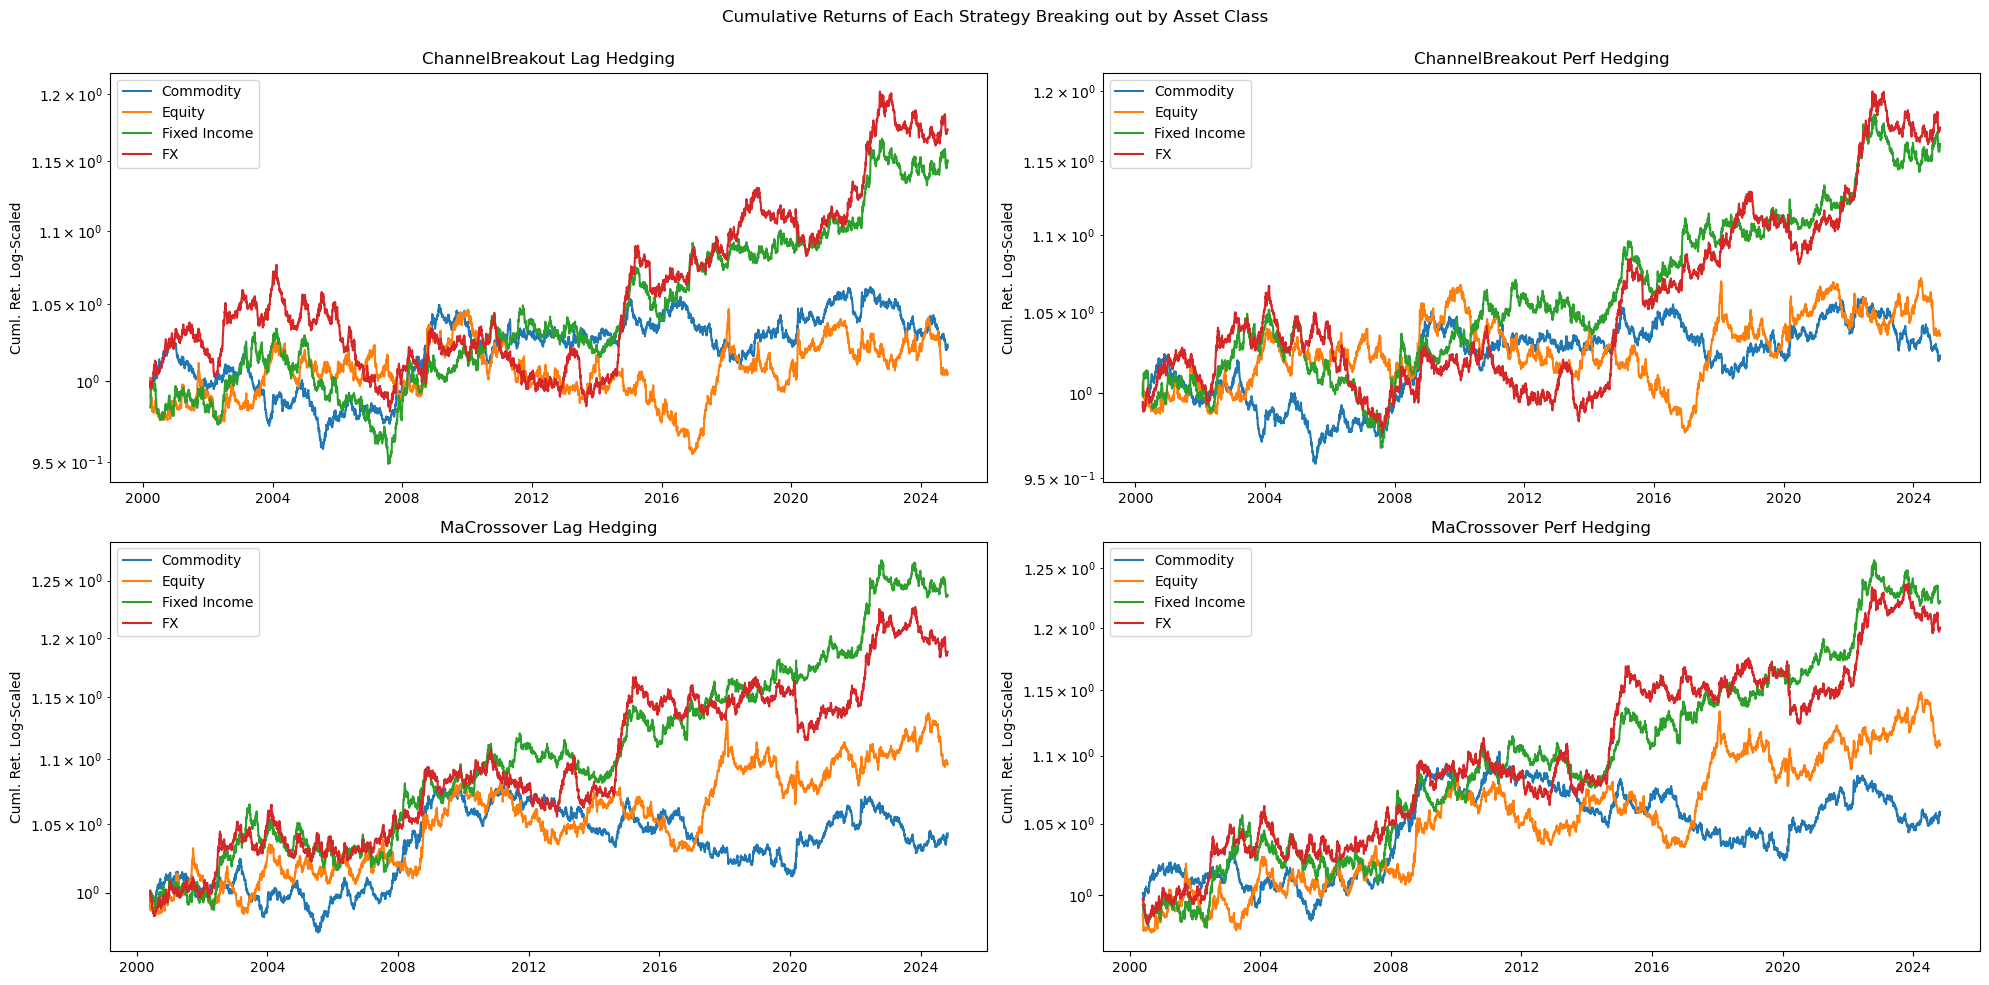

In [33]:
group_vars = df_asset_rtn.group.drop_duplicates().sort_values().to_list()
fig, axes  = plt.subplots(ncols = 2, nrows = 2, figsize = (20,10))

renamer = {
    "commod"      : "Commodity",
    "equity"      : "Equity",
    "fixed_income": "Fixed Income",
    "fx"          : "FX"}

for group_var, ax in zip(group_vars, axes.flatten()): 

    (df_asset_rtn.query(
        "group == @group_var").
        rename(columns = {"asset_class": ""}).
        pivot(index = "date", columns = "", values = "value").
        dropna().
        rename(columns = renamer).
        apply(lambda x: np.cumprod(1 + x)).
        plot(
            ax     = ax,
            title  = group_var + " Hedging",
            logy   = True,
            ylabel = "Cuml. Ret. Log-Scaled",
            xlabel = ""))

fig.suptitle("Cumulative Returns of Each Strategy Breaking out by Asset Class\n")
plt.tight_layout()

In [34]:
df_combined = (df_asset_rtn.assign(
    date  = lambda x: pd.to_datetime(x.date),
    group = lambda x: x.group + " " + x.asset_class.map(renamer)).
    pivot(index = "date", columns = "group", values = "value").
    merge(right = df_cta, how = "inner", on = ["date"]).
    merge(right = df_trend, how = "inner", on = ["date"]).
    dropna())

In [35]:
AQTools().get_perform_results(df_combined)

,CAGR,MaxDD,Ann. Vol.,Ann. Rtn / MaxDD,Sharpe
variable,,,,,
ChannelBreakout Lag Commodity,0.001097,-0.066811,0.001016,0.018356,0.076037
ChannelBreakout Lag Equity,0.001752,-0.087938,0.001211,0.022006,0.100694
ChannelBreakout Lag FX,0.006881,-0.088862,0.001329,0.079686,0.335555
ChannelBreakout Lag Fixed Income,0.006540,-0.082408,0.001216,0.081381,0.347345
ChannelBreakout Perf Commodity,0.001185,-0.064075,0.000976,0.020356,0.084154
ChannelBreakout Perf Equity,0.002456,-0.085238,0.001165,0.030791,0.141929
ChannelBreakout Perf FX,0.007244,-0.084742,0.001290,0.087662,0.362625
ChannelBreakout Perf Fixed Income,0.006245,-0.079858,0.001174,0.080142,0.343361
MaCrossover Lag Commodity,0.001400,-0.070263,0.001024,0.021795,0.094245


In [36]:
df_ma_map = (df_ma_crossover.assign(
    signal_group = lambda x : np.where(x.lag_signal > 0, "long", "short"),
    signal       = "MaCrossover")
    [["ticker", "signal_group", "date"]])

In [37]:
df_cb_map = (df_channel_breakout.assign(
    signal_group = lambda x : np.where(x.lag_signal > 0, "long", "short"),
    signal       = "ChannelBreakout")
    [["ticker", "signal_group", "date"]])

In [38]:
df_signal_rtn = pd.concat([df_perf, df_lagged])
df_signal_map = pd.concat([df_ma_map, df_cb_map])

In [39]:
df_ls_rtn = (df_signal_rtn.merge(
    right = df_signal_map, how = "inner", on = ["date", "ticker"]).
    drop(columns = ["ticker"]).
    groupby(["date", "signal", "hedging", "signal_group"]).
    agg("mean").
    reset_index().
    assign(group = lambda x: x.signal + " " + x.hedging.str.capitalize()))

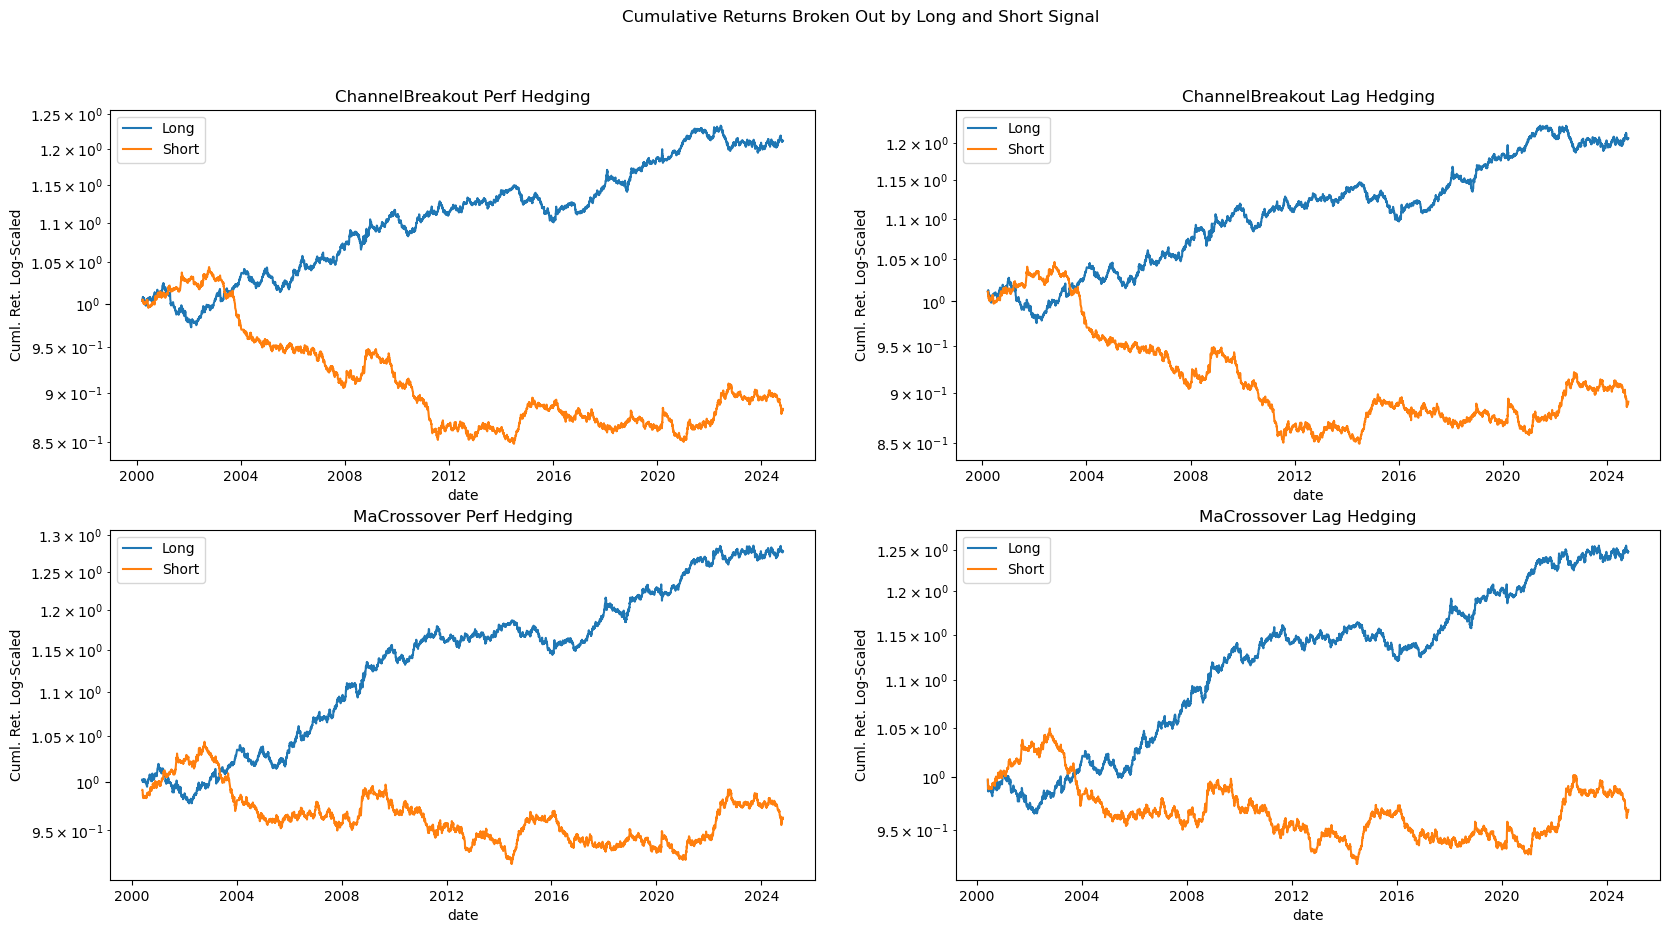

In [40]:
group_vars = df_ls_rtn.group.drop_duplicates().to_list()
fig, axes  = plt.subplots(ncols = 2, nrows = 2, figsize = (20,10))

for group_var, ax in zip(group_vars, axes.flatten()): 

    (df_ls_rtn.query(
        "group == @group_var").
        assign(signal_group = lambda x: x.signal_group.str.capitalize()).
        rename(columns = {"signal_group": ""}).
        pivot(index = "date", columns = "", values = "value").
        dropna().
        apply(lambda x: np.cumprod(1 + x)).
        plot(
            logy   = True,
            ylabel = "Cuml. Ret. Log-Scaled",
            title  = group_var + " Hedging",
            ax     = ax))

fig.suptitle("Cumulative Returns Broken Out by Long and Short Signal\n")
plt.show()